<a href="https://colab.research.google.com/github/catarina1532/avcad/blob/main/projetoAVCAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Relationship between socio-economic variables and agricultural activities in Alentejo parishes

## 1. Introduction

#### **Question**
#### How does the demographic profile of agricultural producers influence land-use patterns in Alentejo?

#### **Hypotheses**
*   H1: Parishes with older agricultural populations have lower prevalence/proportion of temporary crops
*   H2: Higher producer aging is associated with greater prevalence of permanent crops
*   H3: Lower education levels are positively associated with producer aging
*   H4: Aging and education jointly explain variation in agricultural land-use patterns

#### **Objective**
#### Analyze whether demographic aging and educational characteristics of agricultural populations are associated with differences in agricultural land use across Alentejo parishes.

## 2. Database description

### Study design
This study uses a cross-sectional observational design based on parish-level data from Alentejo. Data from multiple agricultural and demographic datasets were integrated using a unique geographic identifier. Derived indicators were subsequently constructed and analyzed using descriptive statistics, exploratory visualizations and inferential methods.

### Auxiliary functions and configuration
Purpose:
*   create reusable functions
*   define cleaning rules

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [129]:
import re

# Função atualizada para extrair também a chave de 6 dígitos do INE
def ler_ine_seguro(filepath, geo_col_idx):
    data = []
    with open(filepath, 'r', encoding='latin-1') as f:
        for line in f:
            cols = line.strip('\n').split(';')
            if len(cols) > geo_col_idx:
                geo_val = cols[geo_col_idx].strip()
                if re.match(r'^\d+:', geo_val):
                    # Extrai os últimos 6 dígitos do código antes dos dois pontos (Chave Única)
                    chave = geo_val.split(':')[0].strip()[-6:]
                    nome = geo_val.split(':')[1].strip()

                    cols[geo_col_idx] = nome
                    # Adiciona a chave no fim para não estragar a contagem das tuas colunas originais
                    cols.append(chave)
                    data.append(cols)
    return pd.DataFrame(data)

def limpar_numerico(serie):
    s = serie.astype(str).str.replace('.', '', regex=False)
    s = s.str.replace(',', '.', regex=False)
    s = s.str.replace(r'^\s*-\s*-\s*$', '0', regex=True)
    return pd.to_numeric(s, errors='coerce').fillna(0)

print("Célula 1 concluída! Funções de tratamento prontas.")

Célula 1 concluída! Funções de tratamento prontas.


### Raw data loading
Purpose:
*   load original files

In [130]:
df_total_raw = ler_ine_seguro('Produtores_Total.csv', geo_col_idx=1)
df_idosos_raw = ler_ine_seguro('Produtores_Idosos.csv', geo_col_idx=0)
df_educacao_raw = ler_ine_seguro('Produtores_Educacao.csv', geo_col_idx=0)
df_culturas_raw = ler_ine_seguro('Superficie_Culturas.csv', geo_col_idx=1)
df_media_raw = ler_ine_seguro('Superficie_Media.csv', geo_col_idx=0)

print("Célula 2 concluída! Os 5 ficheiros foram mapeados e limpos de metadados.")

Célula 2 concluída! Os 5 ficheiros foram mapeados e limpos de metadados.


### Variable extraction
Purpose:
*   select relevant variables
*   rename columns
*   transform raw values into clean variables

In [131]:
# Mapeamento incluindo a Chave_Geo
t_total_clean = pd.DataFrame({
    'Chave_Geo': df_total_raw.iloc[:, -1],
    'Nome_Freguesia': df_total_raw[1],
    'Total_Produtores': limpar_numerico(df_total_raw[2])
})

t_idosos_clean = pd.DataFrame({
    'Chave_Geo': df_idosos_raw.iloc[:, -1],
    'Total_Idosos': limpar_numerico(df_idosos_raw[1])
})

t_educacao_clean = pd.DataFrame({
    'Chave_Geo': df_educacao_raw.iloc[:, -1],
    'Percentagem_Baixa_Escolaridade': limpar_numerico(df_educacao_raw[2]) + limpar_numerico(df_educacao_raw[3])
})

t_culturas_clean = pd.DataFrame({
    'Chave_Geo': df_culturas_raw.iloc[:, -1],
    'Area_Temporarias': limpar_numerico(df_culturas_raw[2]),
    'Area_Permanentes': limpar_numerico(df_culturas_raw[3])
})

t_media_clean = pd.DataFrame({
    'Chave_Geo': df_media_raw.iloc[:, -1],
    'Superficie_Media_Exploracao': limpar_numerico(df_media_raw[1])
})

print("Célula 3 concluída! Variáveis numéricas normalizadas.")

Célula 3 concluída! Variáveis numéricas normalizadas.


### Data integration
Purpose:
*   combine all datasets into a single analytical table

In [132]:
# Cruzamento em cadeia utilizando a Chave_Geo (Única e sem erros de homónimos)
df_final = pd.merge(t_total_clean, t_idosos_clean, on='Chave_Geo', how='inner')
df_final = pd.merge(df_final, t_educacao_clean, on='Chave_Geo', how='inner')
df_final = pd.merge(df_final, t_culturas_clean, on='Chave_Geo', how='inner')

# Usamos 'left' para o 5º ficheiro para NÃO perder as freguesias que faltam!
df_final = pd.merge(df_final, t_media_clean, on='Chave_Geo', how='left')

# Onde o 5º ficheiro não tinha dados, assume 0 para não quebrar os gráficos
df_final['Superficie_Media_Exploracao'] = df_final['Superficie_Media_Exploracao'].fillna(0)

### Variable construction
Purpose:
*   create new derived variables, not integrating data
*   construct Percentagem_Envelhecimento, Area_Total_Culturas, Perc_Temporarias and Perc_Permanentes (analytical variables created from existing ones)


In [133]:
# Construção da taxa de envelhecimento relativo (%)
df_final['Percentagem_Envelhecimento'] = (df_final['Total_Idosos'] / df_final['Total_Produtores']) * 100
df_final['Percentagem_Envelhecimento'] = df_final['Percentagem_Envelhecimento'].fillna(0).round(2)

# Normalização das áreas agrícolas
df_final['Area_Total_Culturas'] = (df_final['Area_Temporarias'] + df_final['Area_Permanentes'])

df_final['Perc_Temporarias'] = (df_final['Area_Temporarias'] / df_final['Area_Total_Culturas'])*100

df_final['Perc_Permanentes'] = (df_final['Area_Permanentes'] / df_final['Area_Total_Culturas'])*100

df_final[['Perc_Temporarias', 'Perc_Permanentes']] = (df_final[['Perc_Temporarias', 'Perc_Permanentes']].fillna(0))

### Exporting final dataset
Purpose:
*   save final dataset

In [134]:
# Gravação do documento final unificado (Removendo a coluna de suporte do índice)
df_final.to_csv('Dataset_Final_Alentejo.csv', index=False, encoding='utf-8')

print(f"Célula 4 concluída! Ficheiro 'Dataset_Final_Alentejo.csv' exportado com {len(df_final)} freguesias reais do Alentejo.")
df_final.head()

Célula 4 concluída! Ficheiro 'Dataset_Final_Alentejo.csv' exportado com 299 freguesias reais do Alentejo.


,Chave_Geo,Nome_Freguesia,Total_Produtores,Total_Idosos,Percentagem_Baixa_Escolaridade,Area_Temporarias,Area_Permanentes,Superficie_Media_Exploracao,Percentagem_Envelhecimento,Area_Total_Culturas,Perc_Temporarias,Perc_Permanentes
0,150106,Comporta,42,17,79,2105,6205,157.5,40.48,8310,25.330927,74.669073
1,150105,São Martinho,23,5,56,1572,300,120.9,21.74,1872,83.974359,16.025641
2,150104,Torrão,157,82,72,3860,3369,167.9,52.23,7229,53.396044,46.603956
3,150107,União das freguesias de Alcácer do Sal (Santa ...,264,94,53,15280,13474,168.1,35.61,28754,53.140433,46.859567
4,150501,Azinheira dos Barros e São Mamede do Sádão,59,28,50,1542,1197,201.4,47.46,2739,56.297919,43.702081


### Descriptive statistics
Purpose:
*   summarize central tendencies
*   summarize variability
*   provide an overview before visualization

In [135]:
# 1. Configurar o estilo visual dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 300, 'font.family': 'sans-serif'})

# 2. Estatística Descritiva Básica (Médias e Totais)
print("--- ESTATÍSTICA DESCRITIVA DO ALENTEJO ---")
print(f"Média de Envelhecimento Agrícola: {df_final['Percentagem_Envelhecimento'].mean():.2f}%")
print(f"Média de Baixa Escolaridade: {df_final['Percentagem_Baixa_Escolaridade'].mean():.2f}%")
print(f"Total de Áreas Temporárias: {df_final['Area_Temporarias'].sum():,.0f} ha")
print(f"Total de Áreas Permanentes: {df_final['Area_Permanentes'].sum():,.0f} ha")
print("-" * 40)

desc = df_final.describe()

print(desc)

--- ESTATÍSTICA DESCRITIVA DO ALENTEJO ---
Média de Envelhecimento Agrícola: 50.58%
Média de Baixa Escolaridade: 69.94%
Total de Áreas Temporárias: 594,749 ha
Total de Áreas Permanentes: 358,550 ha
----------------------------------------
       Total_Produtores  Total_Idosos  Percentagem_Baixa_Escolaridade  \
count        299.000000    299.000000                      299.000000   
mean         113.080268     58.668896                       69.943144   
std           89.082800     48.956707                       10.187180   
min            2.000000      1.000000                       36.000000   
25%           51.500000     25.000000                       63.000000   
50%           85.000000     42.000000                       71.000000   
75%          144.500000     79.000000                       77.000000   
max          554.000000    297.000000                       96.000000   

       Area_Temporarias  Area_Permanentes  Superficie_Media_Exploracao  \
count        299.000000      

The demographic context

*   Aging average: 50.6%
*   Low education: 69.9%

Question: Is agricultural aging changing land use?

## 3. Exploratory Data Analysis

### Distribution plots

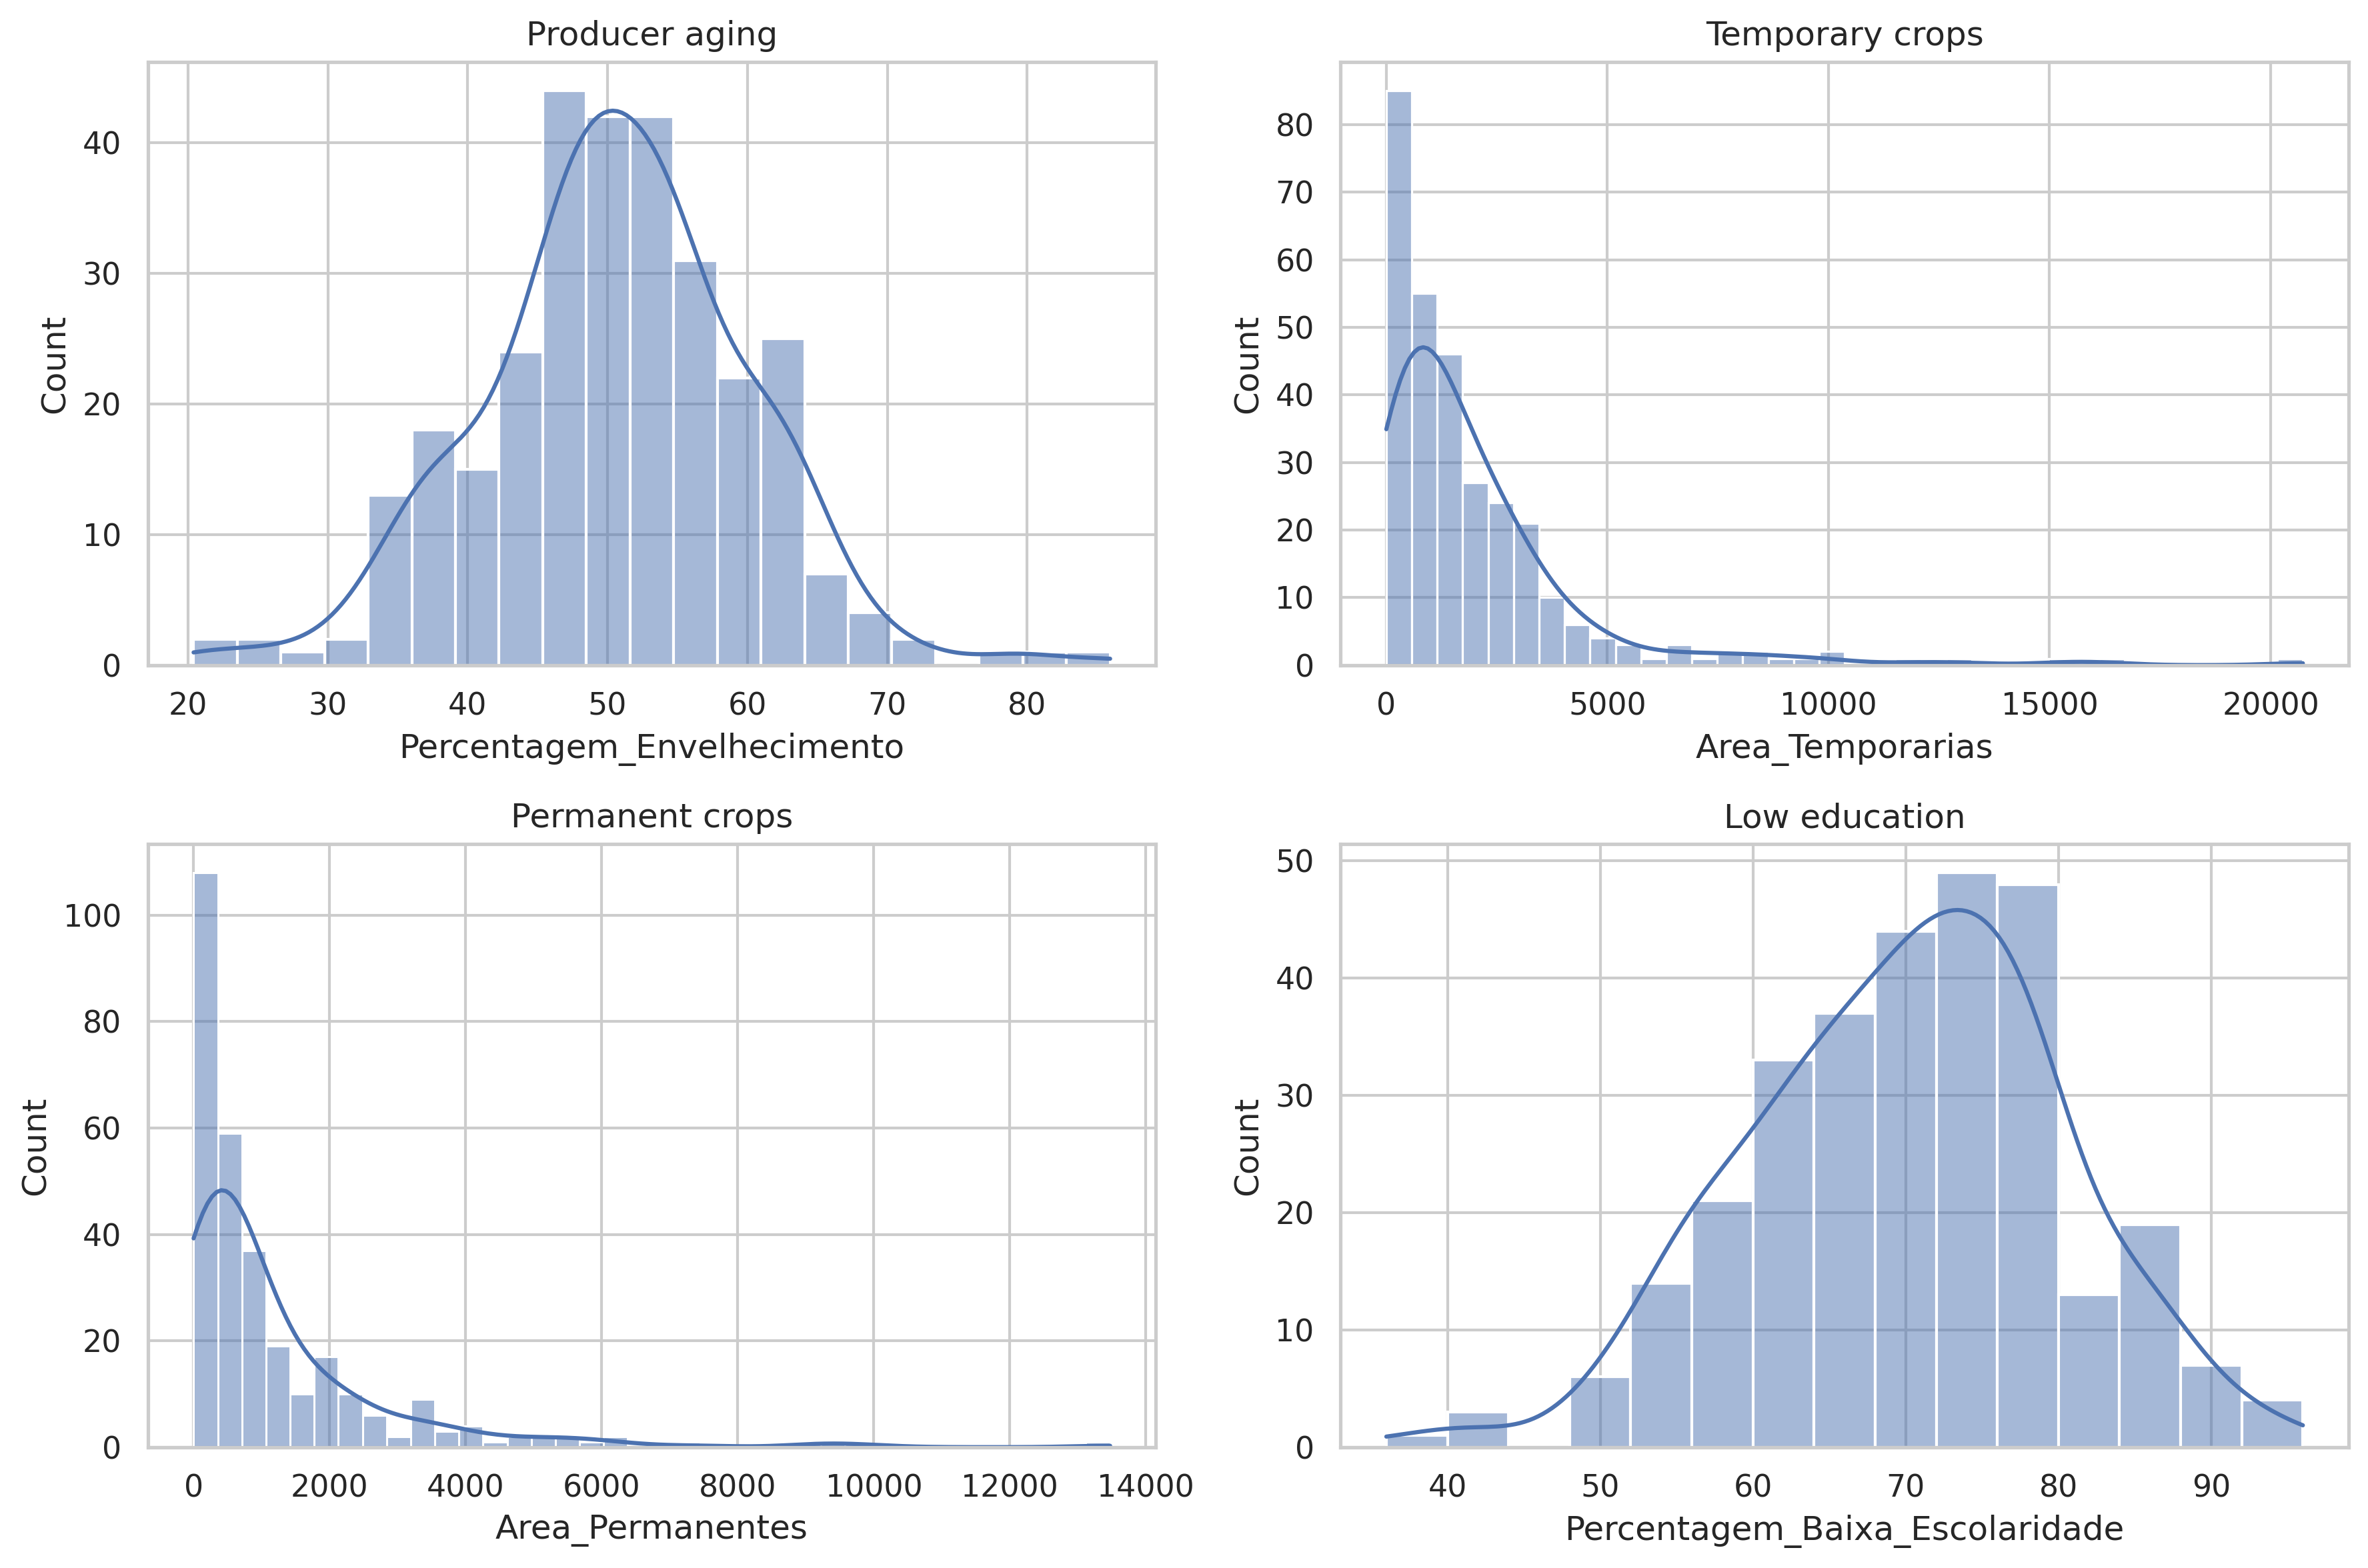

In [155]:
fig, axes = plt.subplots(2,2,figsize=(12,8))

sns.histplot(df_final['Percentagem_Envelhecimento'], ax=axes[0,0], kde=True)
sns.histplot(df_final['Area_Temporarias'], ax=axes[0,1], kde=True)
sns.histplot(df_final['Area_Permanentes'], ax=axes[1,0], kde=True)
sns.histplot(df_final['Percentagem_Baixa_Escolaridade'], ax=axes[1,1], kde=True)

axes[0,0].set_title("Producer aging")
axes[0,1].set_title("Temporary crops")
axes[1,0].set_title("Permanent crops")
axes[1,1].set_title("Low education")

plt.subplots_adjust(hspace=0.5) # Adjust vertical spacing between subplots
plt.tight_layout()
plt.show()

**Aging distribution:** The distribution of producer aging appears approximately symmetric and centered around 50%, suggesting that aging is widespread across Alentejo rather than concentrated in a limited subset of parishes. Extreme low and high values exist but occur infrequently.

**Temporary crop distribution:** Temporary crop percentages exhibit strong positive skewness, with most parishes showing relatively limited temporary cultivation while a smaller number of parishes concentrate large proportions of temporary agricultural activity. The long right tail and visible outliers suggest unequal spatial concentration of agricultural production.

**Permanent crop distribution:** Permanent crop percentages also display positive skewness, although less pronounced than temporary crops. Several extreme observations indicate specialization in agricultural systems such as vineyards or olive production.

**Education distribution:** Low educational attainment shows mild negative skewness because most observations cluster at high percentages. This suggests that low educational levels among agricultural producers are widespread across Alentejo.

### Correlation matrix

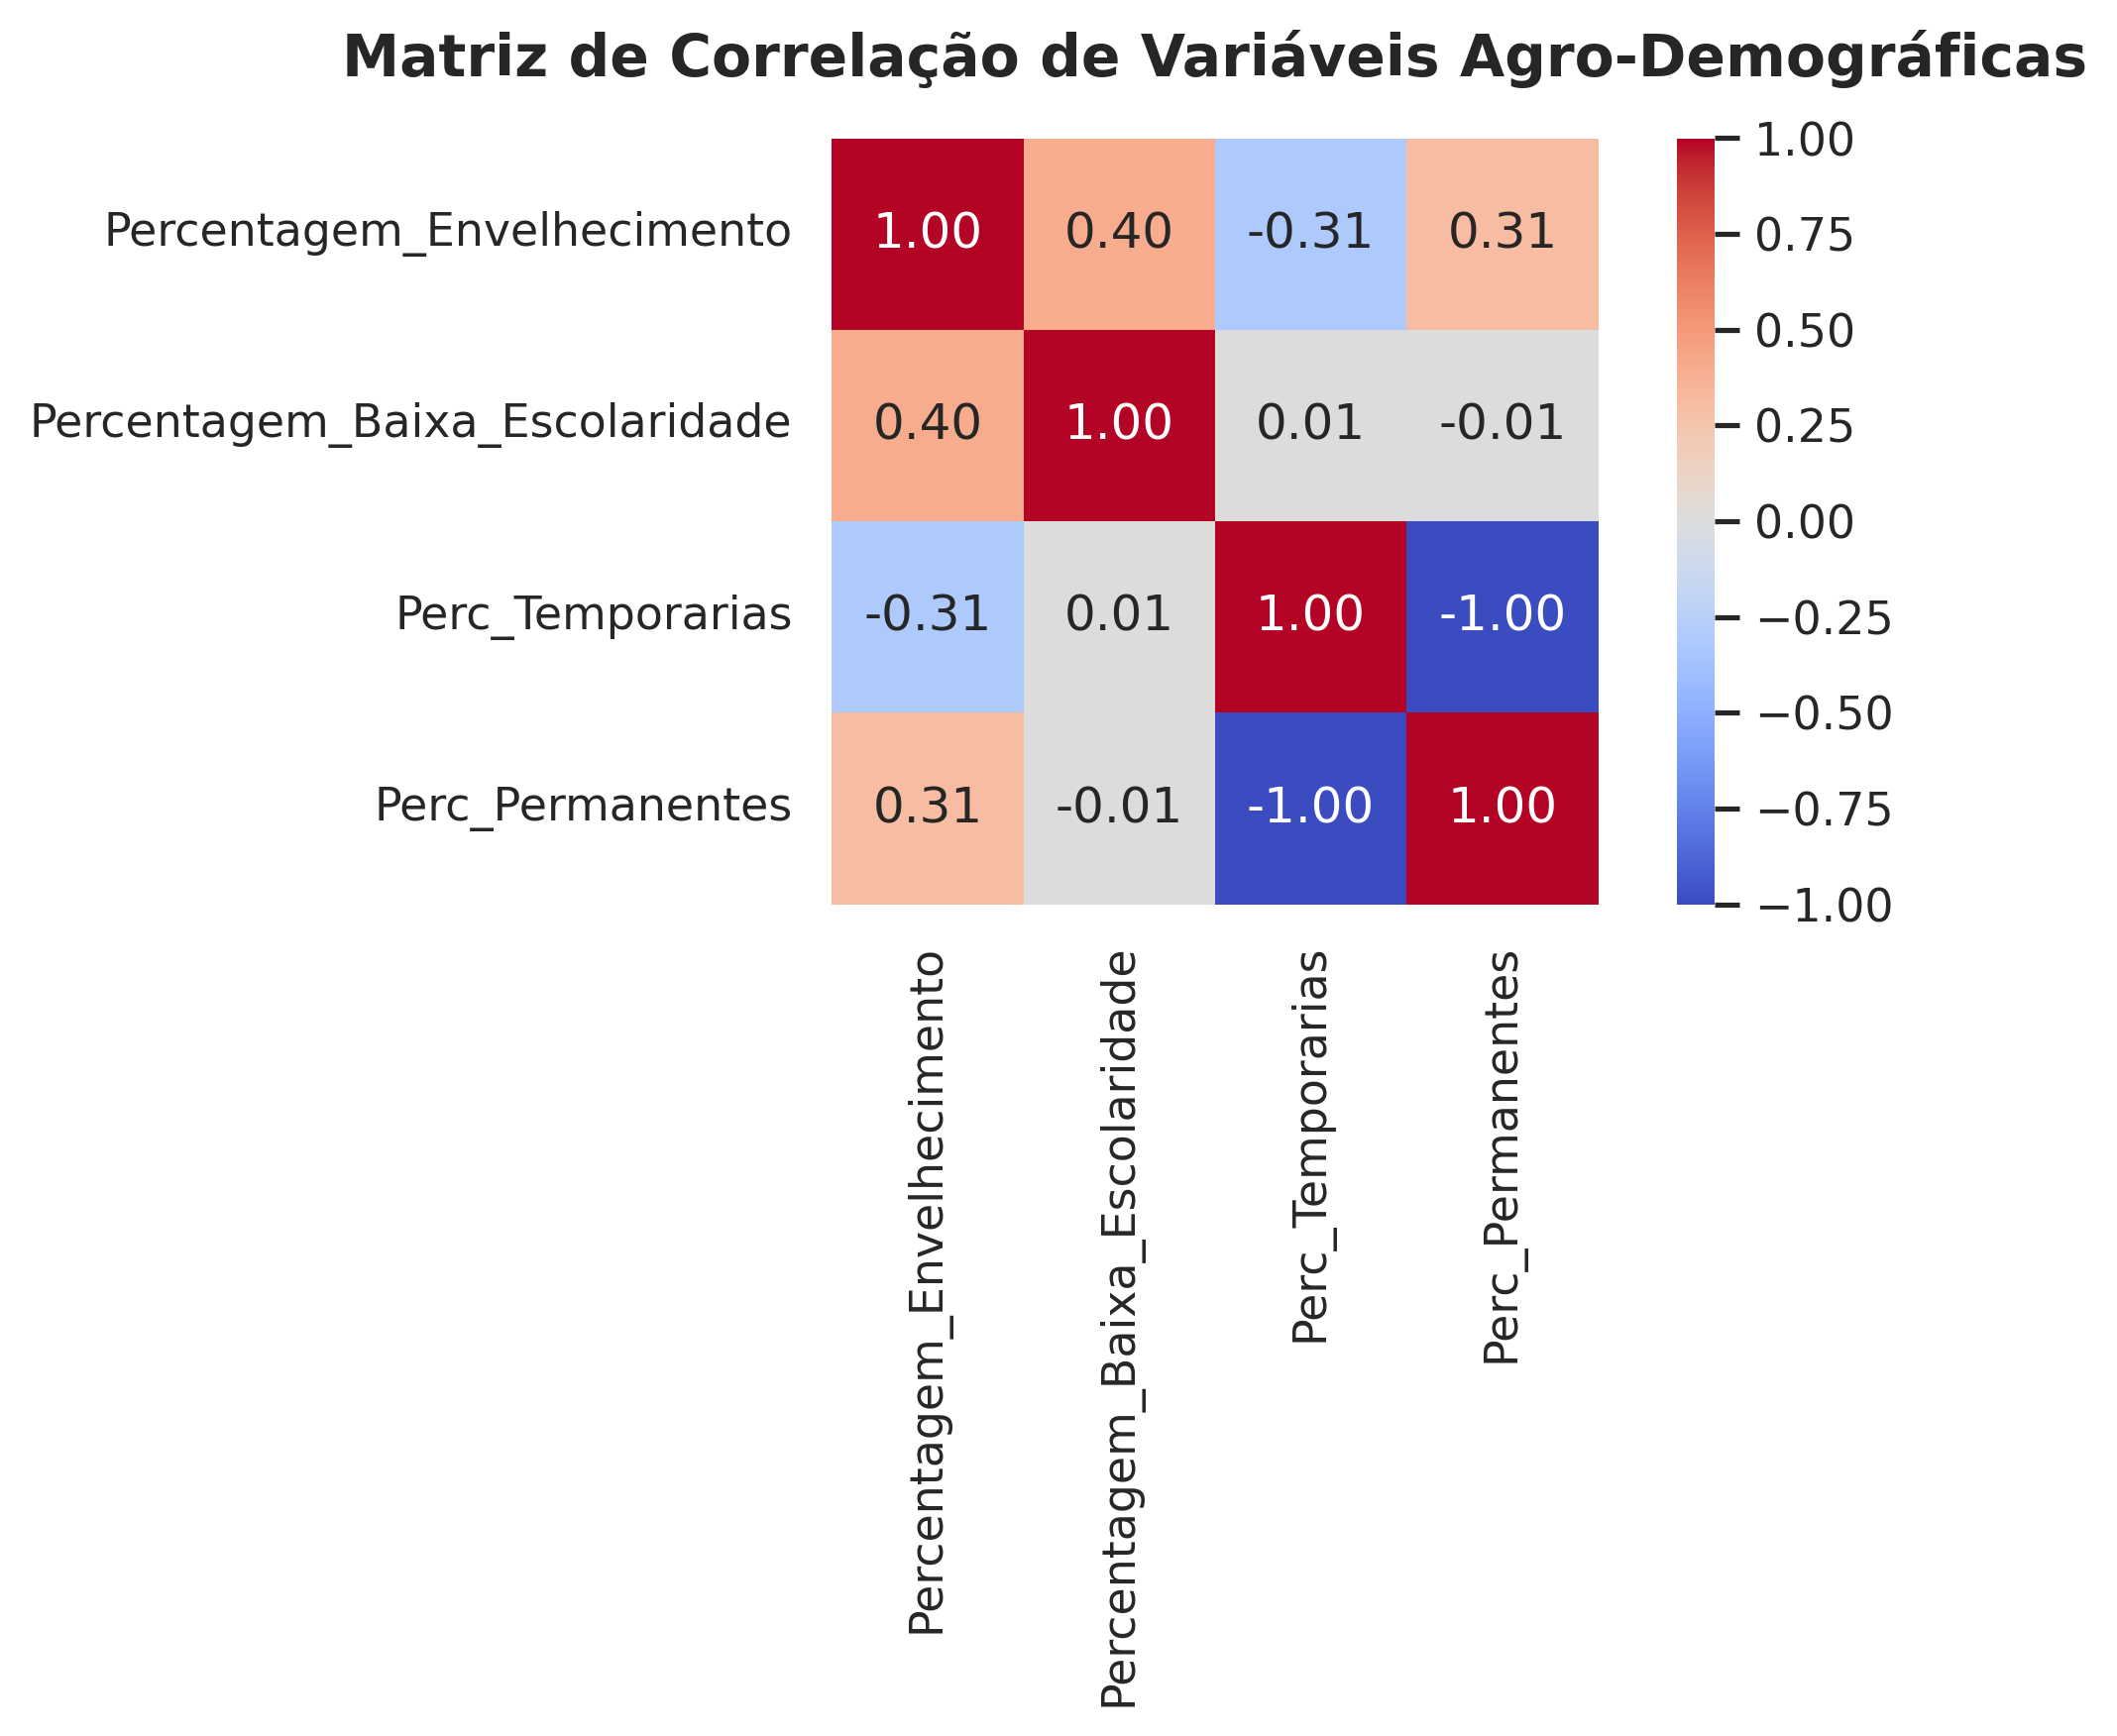

In [150]:
# 3. Matriz de Correlação Simples (Mapa de Calor)
# Selecionar apenas as variáveis que queremos cruzar
cols_corr = ['Percentagem_Envelhecimento', 'Percentagem_Baixa_Escolaridade', 'Perc_Temporarias', 'Perc_Permanentes']
matriz_corr = df_final[cols_corr].corr()

# Desenhar o gráfico
plt.figure(figsize=(8,6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", square=True)
plt.title("Matriz de Correlação de Variáveis Agro-Demográficas", pad=15, fontsize=14, fontweight='bold')
plt.tight_layout()

# Exportar imagem para o Colab e mostrar no ecrã
plt.savefig('Matriz_Correlacao.png')
plt.show()

Relationships:
* Aging vs low education: moderate positive correlation (r=0.40)
* Aging vs temporary crops: moderate negative correlation (r=-0.31)
* Aging vs permanent crops: moderate positive correlation (r=0.31)
* Temporary and permanent crop percentages are perfectly negatively correlated (r=-1.00) because they are complementary proportions summing to 100%
  * Perc_Permanentes=100-Perc_Temporarias
  * The perfect inverse correlation between temporary and permanent crops should not be interpreted as a causal relationship because both variables were constructed from the same total area

### Scatterplots

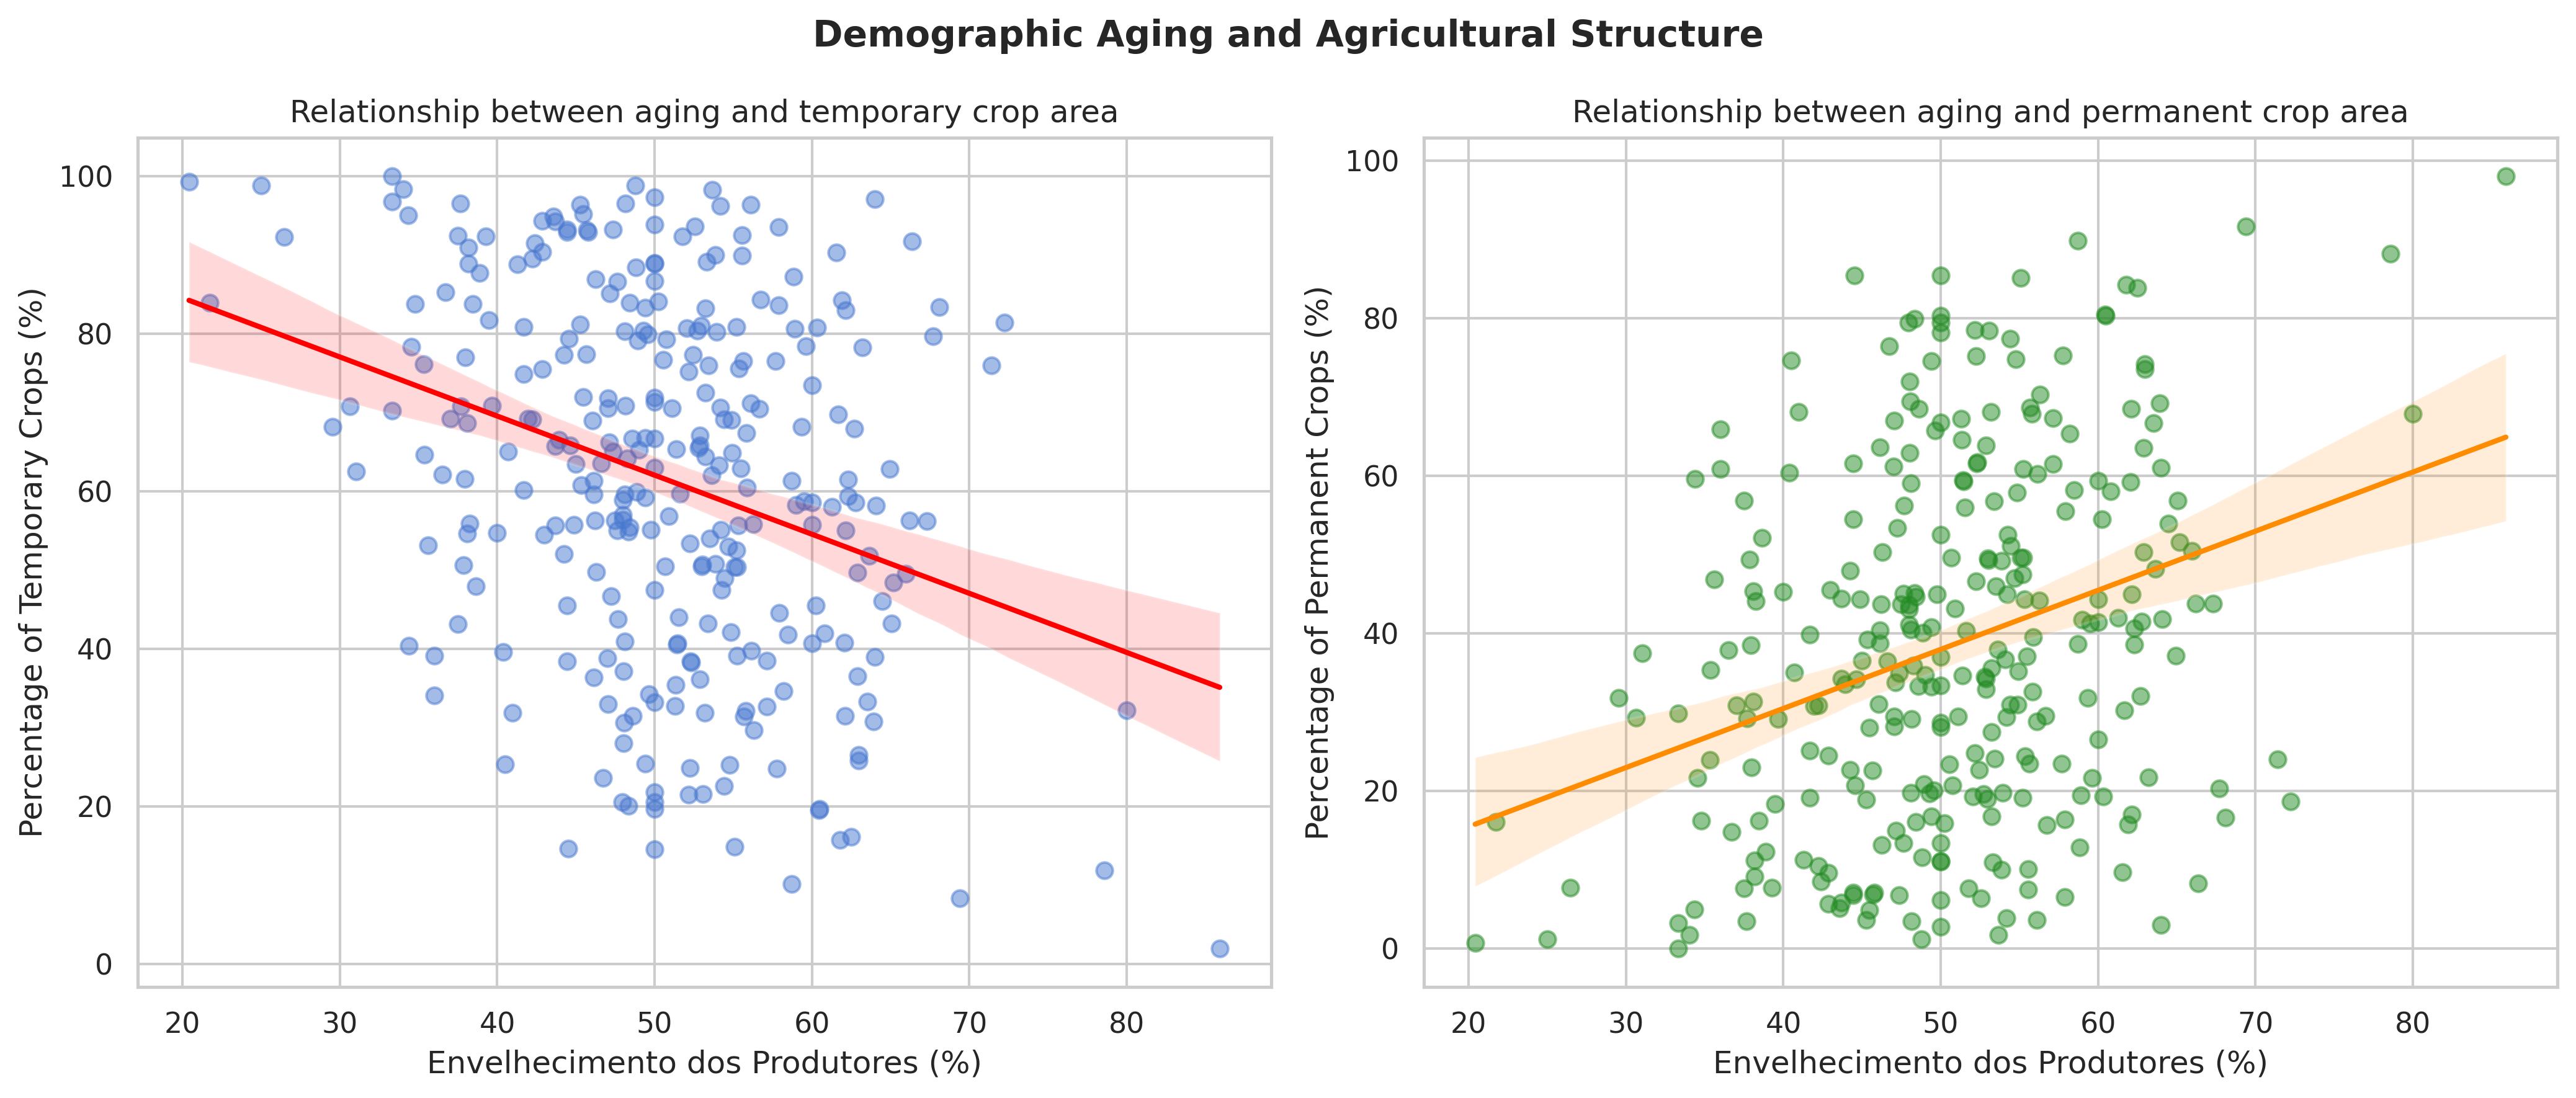

In [123]:
# 4. Gráficos de Dispersão com Linha de Tendência (Regressão)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico A: Envelhecimento vs Culturas Temporárias (Esperamos uma linha a descer)
sns.regplot(data=df_final, x='Percentagem_Envelhecimento', y='Perc_Temporarias',
            scatter_kws={'alpha':0.5, 's':40}, line_kws={'color':'red', 'lw':2}, ax=ax1)
ax1.set_title("Relationship between aging and temporary crop area", fontsize=12)
ax1.set_xlabel("Envelhecimento dos Produtores (%)")
ax1.set_ylabel("Percentage of Temporary Crops (%)")

# Gráfico B: Envelhecimento vs Culturas Permanentes (Esperamos uma linha a subir)
sns.regplot(data=df_final, x='Percentagem_Envelhecimento', y='Perc_Permanentes',
            scatter_kws={'alpha':0.5, 's':40, 'color':'forestgreen'}, line_kws={'color':'darkorange', 'lw':2}, ax=ax2)
ax2.set_title("Relationship between aging and permanent crop area", fontsize=12)
ax2.set_xlabel("Envelhecimento dos Produtores (%)")
ax2.set_ylabel("Percentage of Permanent Crops (%)")

plt.suptitle('Demographic Aging and Agricultural Structure', fontsize=14, fontweight='bold')

plt.tight_layout()

# Exportar imagem para o Colab e mostrar no ecrã
plt.savefig('Graficos_Dispersao.png')
plt.show()

Older producer populations tend to be associated with lower proportions of temporary crops.

### Boxplots

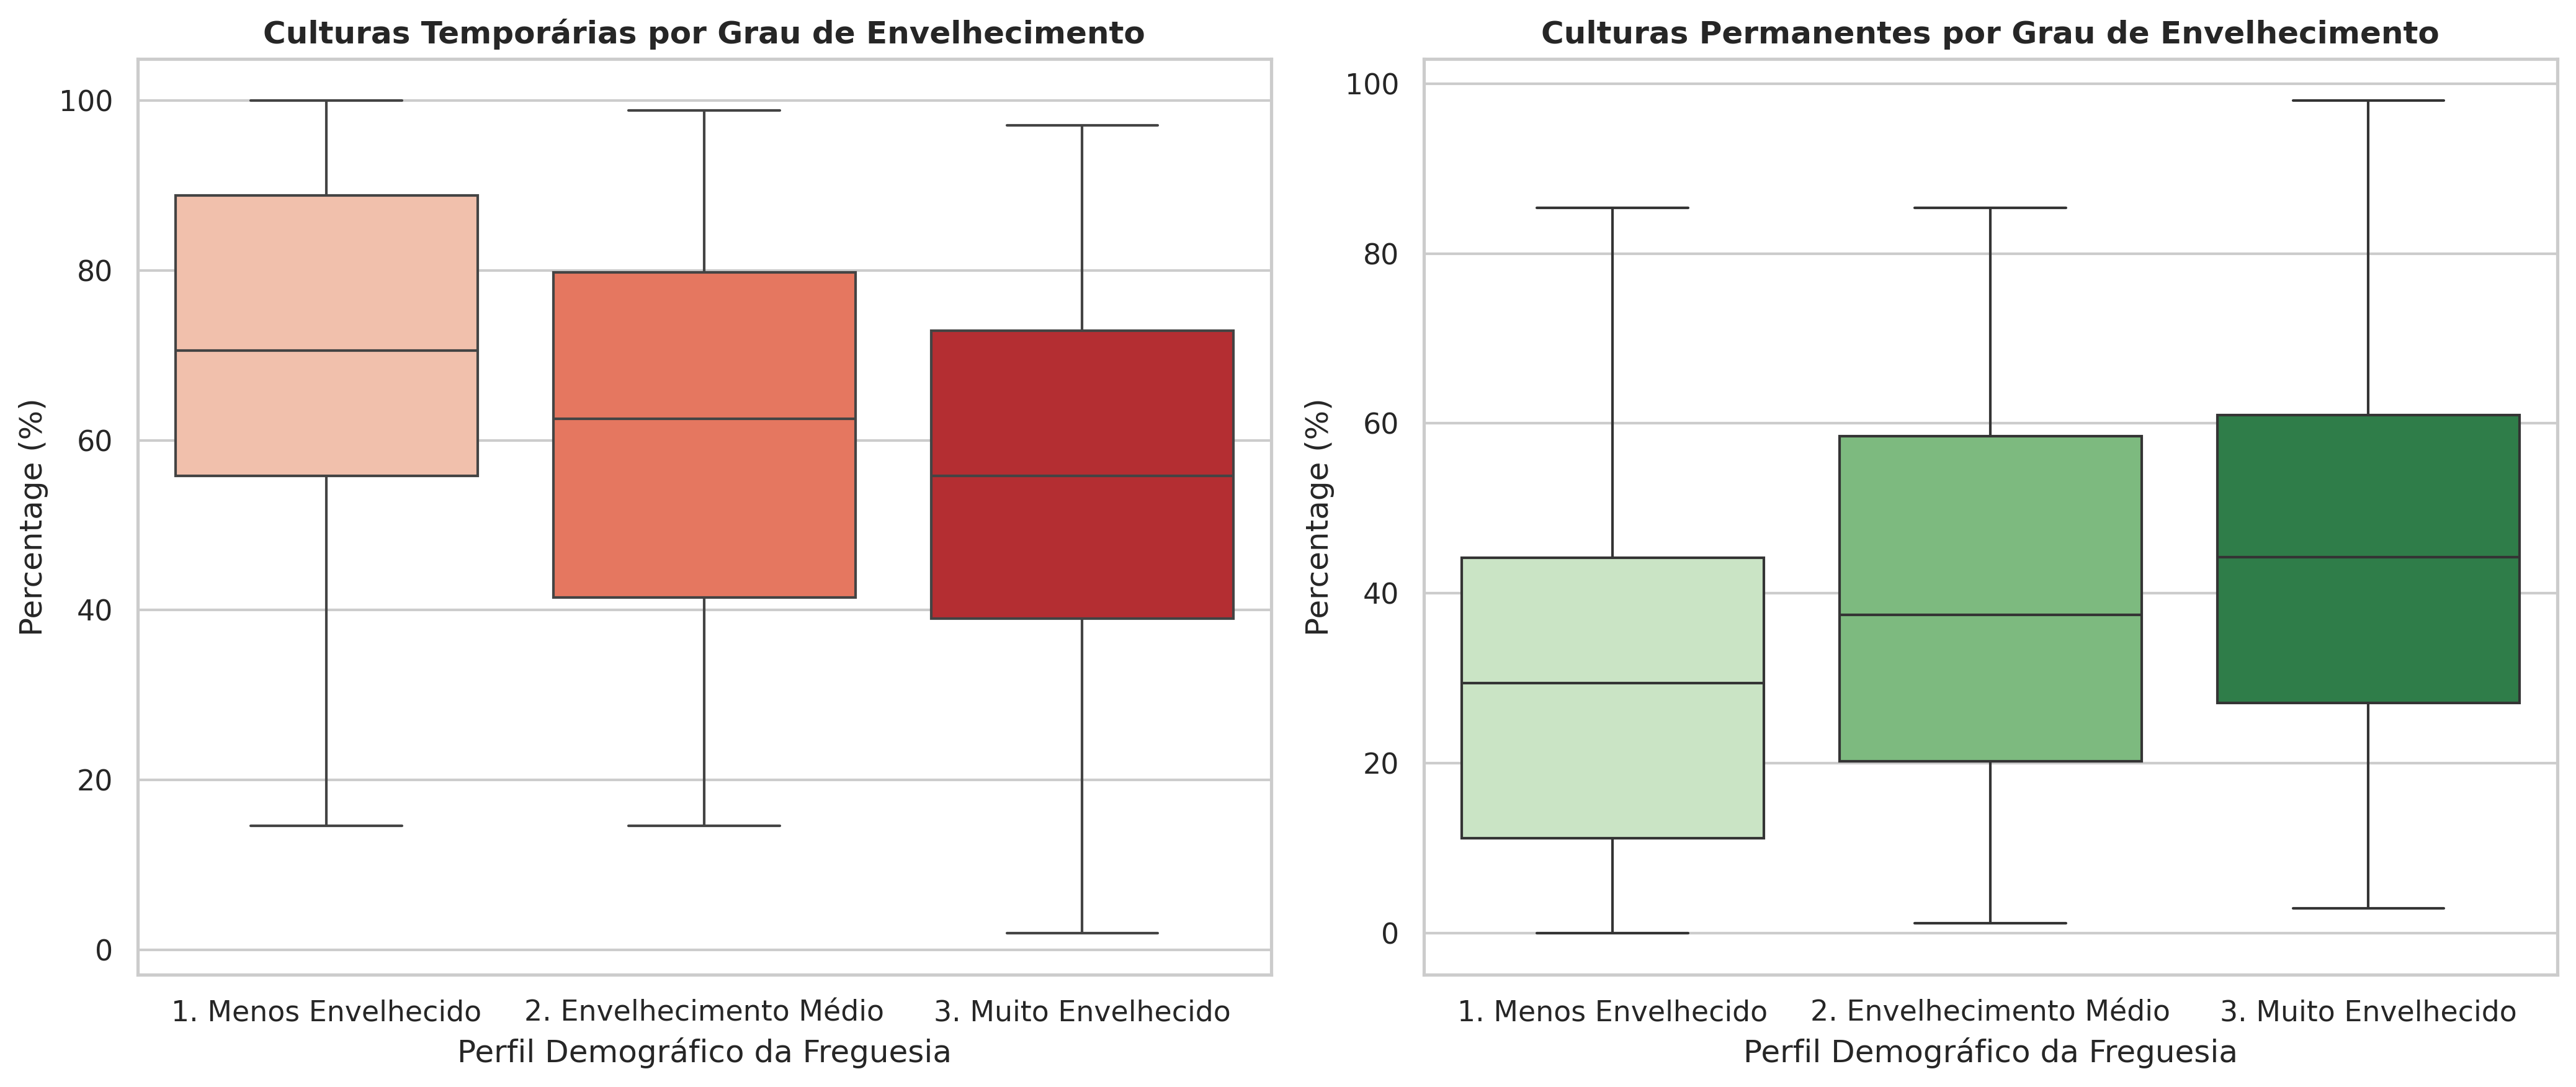

In [146]:
# 1. Criar as categorias de envelhecimento por tercis
tercil_33 = df_final['Percentagem_Envelhecimento'].quantile(0.33)
tercil_66 = df_final['Percentagem_Envelhecimento'].quantile(0.66)

condicoes = [
    (df_final['Percentagem_Envelhecimento'] <= tercil_33),
    (df_final['Percentagem_Envelhecimento'] > tercil_33) & (df_final['Percentagem_Envelhecimento'] <= tercil_66),
    (df_final['Percentagem_Envelhecimento'] > tercil_66)
]
nomes_categorias = ['1. Menos Envelhecido', '2. Envelhecimento Médio', '3. Muito Envelhecido']
df_final['Categoria_Idade'] = np.select(condicoes, nomes_categorias, default='')

# 2. Configurar o estilo visual académico
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 300, 'font.family': 'sans-serif'})

# 3. Desenhar os Boxplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico A: Culturas Temporárias
sns.boxplot(data=df_final, x='Categoria_Idade', y='Perc_Temporarias', hue='Categoria_Idade', palette='Reds', ax=ax1)
ax1.set_title("Culturas Temporárias por Grau de Envelhecimento", fontsize=12, fontweight='bold')
ax1.set_xlabel("Perfil Demográfico da Freguesia")
ax1.set_ylabel("Percentage (%)")

# Gráfico B: Culturas Permanentes
sns.boxplot(data=df_final, x='Categoria_Idade', y='Perc_Permanentes', hue='Categoria_Idade', palette='Greens', ax=ax2)
ax2.set_title("Culturas Permanentes por Grau de Envelhecimento", fontsize=12, fontweight='bold')
ax2.set_xlabel("Perfil Demográfico da Freguesia")
ax2.set_ylabel("Percentage (%)")

plt.tight_layout()
plt.savefig('Grafico_Boxplot_Premium.png')
plt.show()

## 4. Inferential statistics

### Correlation significance

In [125]:
from scipy.stats import pearsonr

corr,p = pearsonr(df_final['Percentagem_Envelhecimento'], df_final['Area_Temporarias'])

print(corr,p)

-0.2757327753090247 1.2848488258579655e-06


A weak negative but statistically significant relationship exists between aging and temporary crop area (r=-0.28, p<0.05)

### ANOVA

In [126]:
from scipy.stats import f_oneway

grupo1 = df_final[df_final['Categoria_Idade']=="1. Menos Envelhecido"]['Area_Temporarias']

grupo2 = df_final[df_final['Categoria_Idade']=="2. Envelhecimento Médio"]['Area_Temporarias']

grupo3 = df_final[df_final['Categoria_Idade']=="3. Muito Envelhecido"]['Area_Temporarias']

f,p = f_oneway(grupo1, grupo2, grupo3)

print(f,p)

15.425676004610098 4.23965918077581e-07


* ANOVA results indicate statistically significant differences between aging groups (F=15.43, p<0.001).

* Parishes with lower aging levels tend to present larger temporary cultivation areas, whereas highly aged parishes generally exhibit smaller temporary crop areas.

* This supports the hypothesis that demographic structure is associated with agricultural land-use patterns.

### Multiple regression

In [143]:
import statsmodels.api as sm

X=df_final[['Percentagem_Envelhecimento', 'Percentagem_Baixa_Escolaridade']]

X=sm.add_constant(X)

y=df_final['Perc_Temporarias']

modelo=sm.OLS(y,X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:       Perc_Temporarias   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     19.81
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           8.42e-09
Time:                        01:26:56   Log-Likelihood:                -1340.5
No. Observations:                 299   AIC:                             2687.
Df Residuals:                     296   BIC:                             2698.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

* The regression model explains approximately 11.8% of the variation in temporary crop prevalence (R²=0.118), indicating limited but statistically significant explanatory power.

* Producer aging shows a statistically significant negative effect (β=-0.91, p<0.001), meaning that higher aging percentages are associated with lower proportions of temporary crops.

* Lower educational attainment presents a positive association (β=0.36, p<0.01), suggesting that socio-demographic characteristics jointly influence agricultural structure.

* Although statistically significant, the relatively low R² indicates that additional economic, environmental, or structural variables may explain agricultural land-use variation.

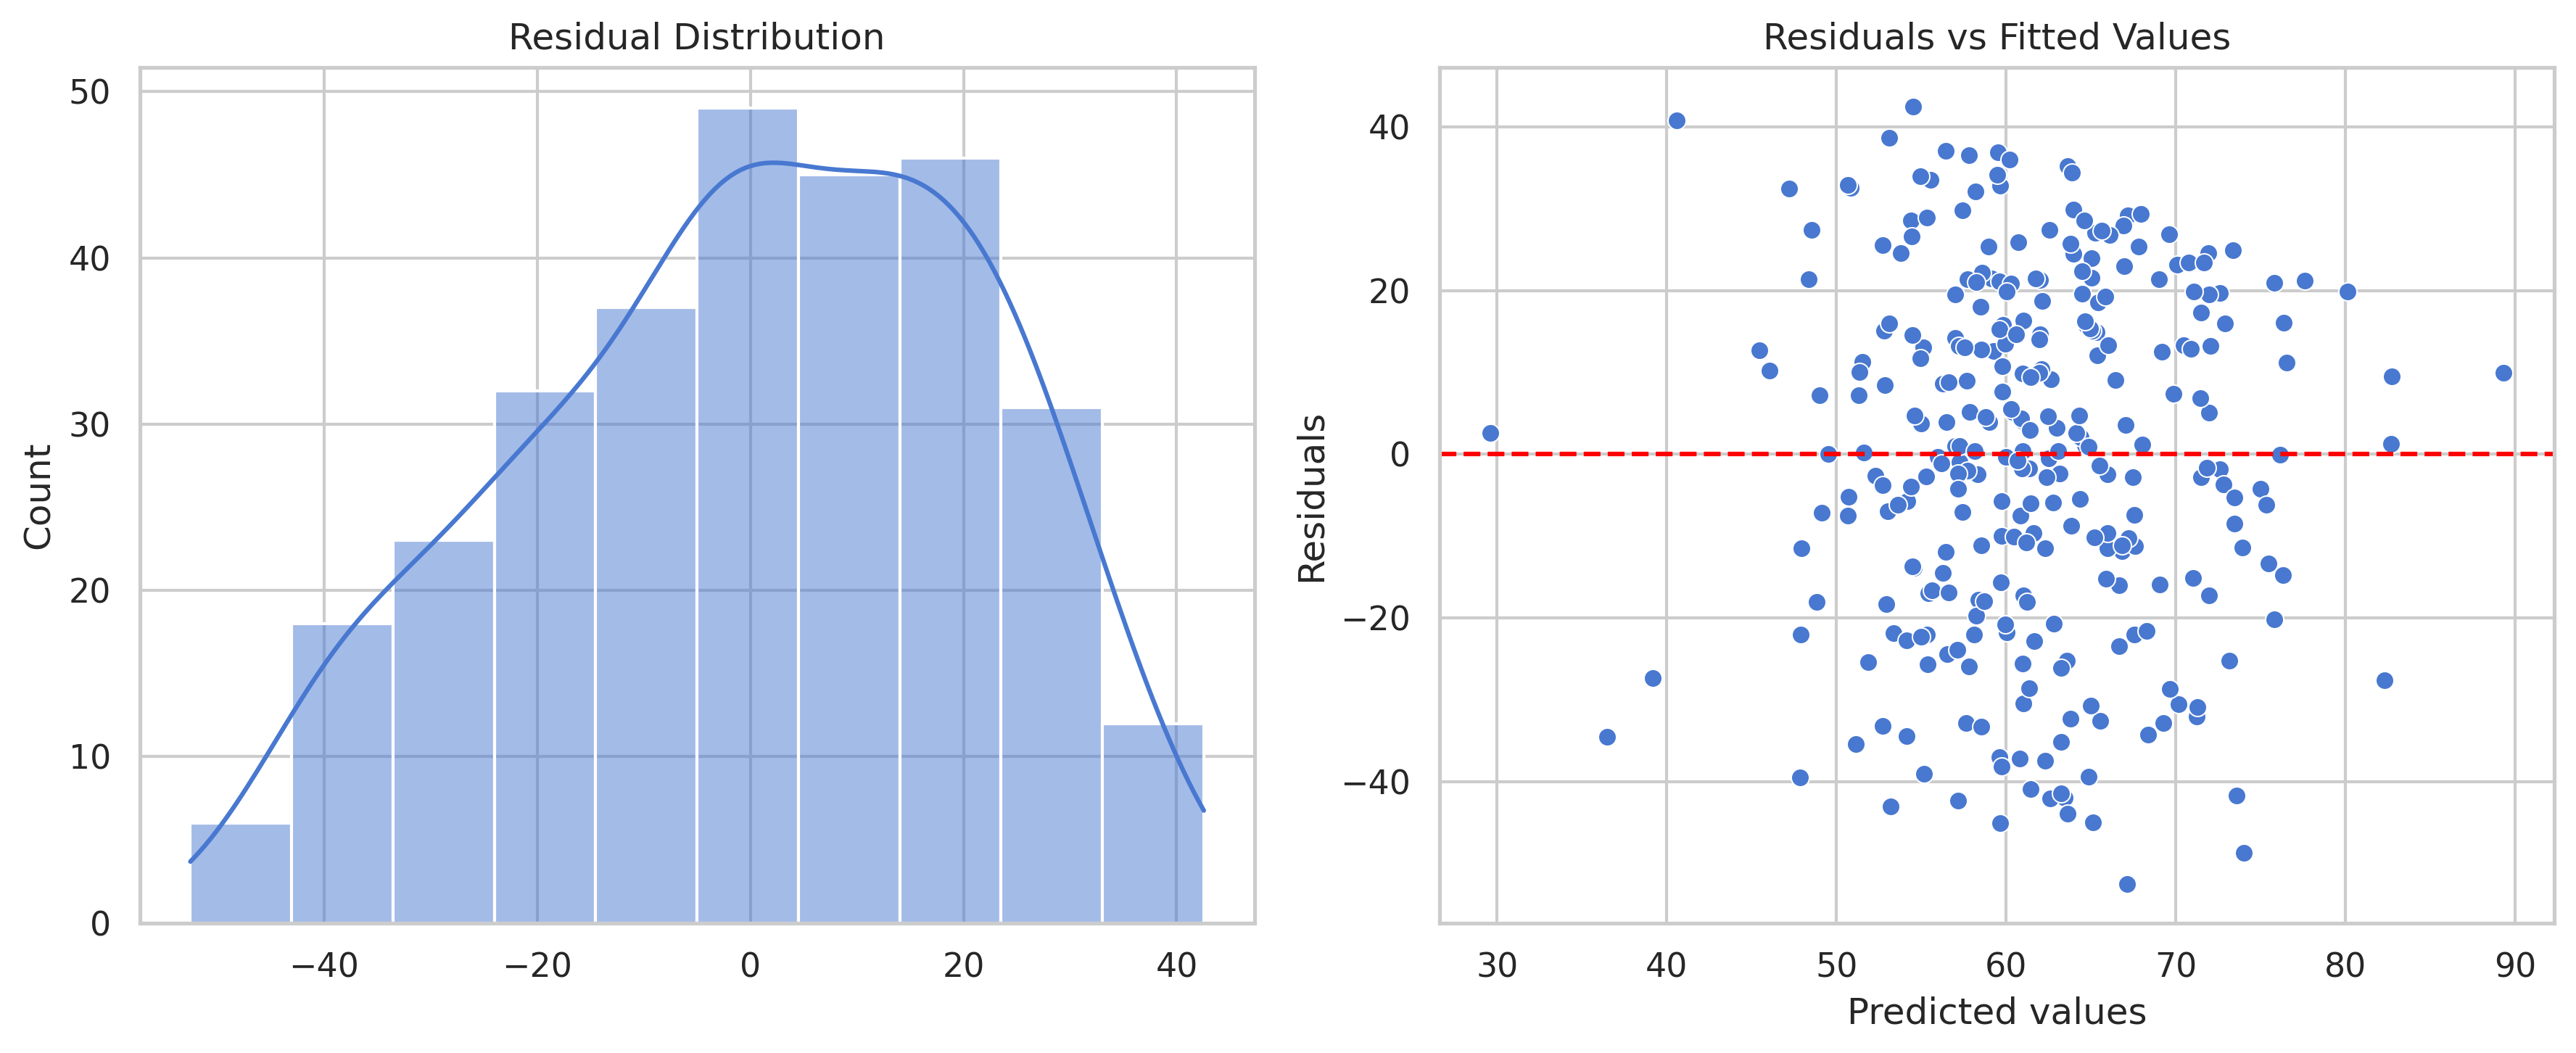

In [140]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

# Residual distribution
sns.histplot(modelo.resid, kde=True, ax=ax[0])
ax[0].set_title("Residual Distribution")

# Residuals vs fitted values
sns.scatterplot(
    x=modelo.fittedvalues,
    y=modelo.resid,
    ax=ax[1]
)

ax[1].axhline(
    y=0,
    linestyle='--',
    color='red'
)

ax[1].set_title("Residuals vs Fitted Values")
ax[1].set_xlabel("Predicted values")
ax[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

Residual inspection suggests whether model assumptions of homoscedasticity and approximate normality are satisfied.

### Multicollinearity
Check if the two predictors Percentagem_Envelhecimento and Percentagem_Baixa_Escolaridade are too correlated.

In [141]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(
        X.values,i
    )
    for i in range(X.shape[1])
]

print(vif)

                         Variable        VIF
0                           const  56.416854
1      Percentagem_Envelhecimento   1.189974
2  Percentagem_Baixa_Escolaridade   1.189974


VIF values below 5 indicate that multicollinearity is unlikely to affect coefficient estimates.

### Interactive exploration

In [156]:
import plotly.express as px

fig=px.scatter(
    df_final,
    x='Percentagem_Envelhecimento',
    y='Perc_Temporarias',
    color='Percentagem_Baixa_Escolaridade',
    hover_name='Nome_Freguesia'
)

fig.show()

The interactive figure allows detailed inspection of parish-level observations and identification of local outliers.

Regression + ANOVA

Observation: Aging remains statistically associated with agricultural structure.

## 5. Study limitations
Several limitations should be acknowledged:
* The analysis is cross-sectional and does not establish causality
* Agricultural land-use patterns may also depend on environmental, economic and institutional factors not included in the datase
* The regression model explains a limited proportion of variance, suggesting omitted variables
* Some variables were transformed into percentages, which may hide differences in absolute agricultural scale between parishes
* Spatial dependence between neighboring parishes was not modeled
* Administrative units differ substantially in area and agricultural structure

## 6. Conclusions
#### The results provide partial support for the proposed hypotheses. Higher producer aging was associated with lower proportions of temporary crops and with higher levels of low educational attainment. Regression analysis further indicated that demographic variables contribute significantly to explaining agricultural structure, although additional environmental and economic factors likely play an important role.